In [1]:
import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
BAD, GOOD, NEUTRAL, ACCENT = "#c0392b", "#1e8449", "#7f8c8d", "#2c6fbb"
RES = "../data/results/"


# P2 - Underpowered tests and the winner's curse

## 1. What goes wrong
With low power the only way to reach significance is to overestimate the effect. Significant results from small tests are exaggerated, and some even have the wrong sign.

## 2. Simulate

In [2]:
from abtest.pitfalls import winners_curse
wc = winners_curse.exaggeration_vs_power(n_sims=20_000)
wc.round(3)

,target_power,n_per_arm,power,exaggeration_ratio,wrong_sign_share
0,0.1,1832,0.101,4.115,0.038
1,0.2,4977,0.200,2.399,0.005
2,0.3,8201,0.298,1.885,0.001
3,0.5,15286,0.497,1.446,0.000
4,0.7,24559,0.704,1.216,0.000
5,0.8,31231,0.804,1.135,0.000
6,0.9,41810,0.903,1.066,0.000


## 3. Quantify the damage

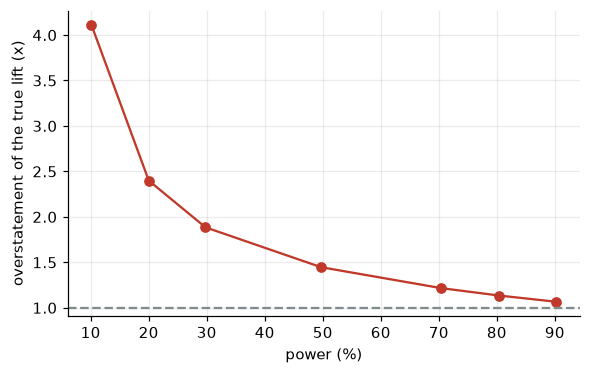

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(wc.power * 100, wc.exaggeration_ratio, 'o-', color=BAD); ax.axhline(1, color=NEUTRAL, ls='--')
ax.set(xlabel='power (%)', ylabel='overstatement of the true lift (x)'); plt.show()

## 4. Detect

Compare the achieved minimum detectable effect with the lift you observed. If the observed lift is near or below the MDE and significant, treat it as exaggerated (health checker: **Power**).

## 5. Fix

Size the test with a power analysis before launch and commit to a minimum detectable effect.

In [4]:
from abtest.analyze.power import sample_size_proportions
print('users per arm for 80% power to detect +10% on a 5% base:', f'{sample_size_proportions(0.05, 0.10):,}')

users per arm for 80% power to detect +10% on a 5% base: 31,231


## 6. Verify the fix

In [5]:
print(wc[['target_power','power','exaggeration_ratio','wrong_sign_share']].round(3).to_string(index=False))

 target_power  power  exaggeration_ratio  wrong_sign_share
          0.1  0.101               4.115             0.038
          0.2  0.200               2.399             0.005
          0.3  0.298               1.885             0.001
          0.5  0.497               1.446             0.000
          0.7  0.704               1.216             0.000
          0.8  0.804               1.135             0.000
          0.9  0.903               1.066             0.000


## So what
At 10% power a 'significant' result overstated the real lift about 4x; at 80% power the overstatement is about 14%. Underpowered tests do not just miss wins, they report lucky overestimates as the truth.